# 10 TF-IDF Word + Char A/B Swap Smoothing Experiment

This notebook extends the current best TF-IDF Logistic Regression method with word-level and char-level TF-IDF features, A/B swap augmentation, swap-test averaging, and probability smoothing.

## 1. Imports and Path Setup

Set up libraries, constants, paths, and output folders.

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, log_loss
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 160)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
LABELS = [0, 1, 2]
LABEL_NAME_MAP = {0: 'A_win', 1: 'B_win', 2: 'tie'}
TARGET_NAMES = [LABEL_NAME_MAP[label] for label in LABELS]

current_dir = Path.cwd().resolve()
if current_dir.name.lower() == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = current_dir

processed_data_dir = project_root / 'data' / 'processed'
figures_dir = project_root / 'outputs' / 'figures'
logs_dir = project_root / 'outputs' / 'logs'
models_dir = project_root / 'outputs' / 'models'
oof_dir = project_root / 'outputs' / 'oof'
submissions_dir = project_root / 'outputs' / 'submissions'

for output_dir in [figures_dir, logs_dir, models_dir, oof_dir, submissions_dir]:
    output_dir.mkdir(parents=True, exist_ok=True)

train_path = processed_data_dir / 'train_eda.csv'
test_path = processed_data_dir / 'test_eda.csv'

print(f'Project root: {project_root}')
print(f'train_eda.csv exists: {train_path.exists()} -> {train_path}')
print(f'test_eda.csv exists: {test_path.exists()} -> {test_path}')

Project root: D:\LLM_Classification_finetuning
train_eda.csv exists: True -> D:\LLM_Classification_finetuning\data\processed\train_eda.csv
test_eda.csv exists: True -> D:\LLM_Classification_finetuning\data\processed\test_eda.csv


## 2. Read Processed Data

Load processed train and test data. Raw data is not used.

In [2]:
train = pd.read_csv(train_path, encoding='utf-8-sig')
test = pd.read_csv(test_path, encoding='utf-8-sig')

print(f'train shape: {train.shape}')
print(f'test shape: {test.shape}')
print('\ntrain columns:')
print(train.columns.tolist())
print('\ntest columns:')
print(test.columns.tolist())
display(train.head(3))
display(test.head(3))

train shape: (57477, 20)
test shape: (3, 12)

train columns:
['id', 'model_a', 'model_b', 'winner_model_a', 'winner_model_b', 'winner_tie', 'label_sum', 'label', 'label_name', 'prompt_clean', 'response_a_clean', 'response_b_clean', 'prompt_char_len', 'response_a_char_len', 'response_b_char_len', 'response_len_diff', 'prompt_word_len', 'response_a_word_len', 'response_b_word_len', 'response_word_len_diff']

test columns:
['id', 'prompt_clean', 'response_a_clean', 'response_b_clean', 'prompt_char_len', 'response_a_char_len', 'response_b_char_len', 'response_len_diff', 'prompt_word_len', 'response_a_word_len', 'response_b_word_len', 'response_word_len_diff']


,id,model_a,model_b,winner_model_a,winner_model_b,winner_tie,label_sum,label,label_name,prompt_clean,response_a_clean,response_b_clean,prompt_char_len,response_a_char_len,response_b_char_len,response_len_diff,prompt_word_len,response_a_word_len,response_b_word_len,response_word_len_diff
0,30192,gpt-4-1106-preview,gpt-4-0613,1,0,0,1,0,A_win,"Is it morally right to try to have a certain percentage of females on managerial positions?\nOK, does pineapple belong on a pizza? Relax and give me fun ans...",The question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves cons...,"As an AI, I don't have personal beliefs or opinions. However, I can tell you that the question of gender quotas in managerial positions is a complex one and...",159,4459,1200,3259,29,674,205,469
1,53567,koala-13b,gpt-4-0613,0,1,0,1,1,B_win,What is the difference between marriage license and marriage certificate?\nHow can I get both of them as quick as possible in California \nWhat is the minim...,"A marriage license is a legal document that allows a couple to get married. It is issued by a government agency, such as a county clerk's office or a state ...",A marriage license and a marriage certificate are two different legal documents that have separate purposes.\n\n1. Marriage License: A marriage license is a...,192,3096,3592,-496,36,539,579,-40
2,65089,gpt-3.5-turbo-0613,mistral-medium,0,0,1,1,2,tie,explain function calling. how would you call a function?,"Function calling is the process of invoking or executing a function in a programming language. To call a function, you need to use the function's name follo...",Function calling is the process of invoking a function in a program. A function is a block of code that performs a specific task and can be reused multiple ...,56,884,1796,-912,9,147,297,-150


,id,prompt_clean,response_a_clean,response_b_clean,prompt_char_len,response_a_char_len,response_b_char_len,response_len_diff,prompt_word_len,response_a_word_len,response_b_word_len,response_word_len_diff
0,136060,"I have three oranges today, I ate an orange yesterday. How many oranges do I have?",You have two oranges today.,You still have three oranges. Eating an orange yesterday does not affect the number of oranges you have today.,82,27,110,-83,16,5,19,-14
1,211333,"You are a mediator in a heated political debate between two opposing parties. Mr Reddy is very hung up on semantic definitions of sex and gender, and believ...","Thank you for sharing the details of the situation. As a mediator, I understand the importance of finding a middle ground that both parties can agree upon.\...","Mr Reddy and Ms Blue both have valid points in their arguments. On one hand, Mr Reddy is correct that women are adult human females, as defined by their bio...",484,1445,456,989,84,221,75,146
2,1233961,"How to initialize the classification head when I do transfer learning. For example, I have a pre-trained vision transformer on ImageNet, and now I want to f...","When you want to initialize the classification head for transfer learning, you can follow these steps:\n\n 1. Load the pre-trained model: First, load the p...","To initialize the classification head when performing transfer learning, follow these steps:\n\n1. Load the pre-trained vision transformer model that was tr...",211,3961,3648,313,36,626,481,145


## 3. Column Check

Validate columns needed for labels, clean text, A/B swapping, and saved outputs.

In [3]:
required_train_columns = {
    'id',
    'label',
    'label_name',
    'prompt_clean',
    'response_a_clean',
    'response_b_clean',
    'response_a_char_len',
    'response_b_char_len',
    'response_len_diff',
}
required_test_columns = {'id', 'prompt_clean', 'response_a_clean', 'response_b_clean'}

missing_train_columns = sorted(required_train_columns - set(train.columns))
missing_test_columns = sorted(required_test_columns - set(test.columns))

if missing_train_columns:
    raise ValueError(f'train_eda.csv missing columns: {missing_train_columns}')
if missing_test_columns:
    raise ValueError(f'test_eda.csv missing columns: {missing_test_columns}')

train['label'] = train['label'].astype(int)

print('Column check passed.')
print('\nLabel counts:')
display(train['label_name'].value_counts().reindex(TARGET_NAMES))

Column check passed.

Label counts:


label_name
A_win    20064
B_win    19652
tie      17761
Name: count, dtype: int64

## 4. Helper Functions

Define text construction, A/B swapping, feature transformation, probability alignment, and smoothing helpers.

In [4]:
def build_text_input(df):
    prompt = df['prompt_clean'].fillna('').astype(str)
    response_a = df['response_a_clean'].fillna('').astype(str)
    response_b = df['response_b_clean'].fillna('').astype(str)

    return (
        'Prompt:\n' + prompt
        + '\n\nResponse A:\n' + response_a
        + '\n\nResponse B:\n' + response_b
    )


def swap_ab_dataframe(df):
    swapped = df.copy()
    swapped['response_a_clean'] = df['response_b_clean'].values
    swapped['response_b_clean'] = df['response_a_clean'].values

    if {'response_a_char_len', 'response_b_char_len'}.issubset(swapped.columns):
        swapped['response_a_char_len'] = df['response_b_char_len'].values
        swapped['response_b_char_len'] = df['response_a_char_len'].values

    if 'response_len_diff' in swapped.columns:
        swapped['response_len_diff'] = swapped['response_a_char_len'] - swapped['response_b_char_len']

    if 'label' in swapped.columns:
        swapped['label'] = df['label'].map({0: 1, 1: 0, 2: 2}).astype(int).values
        swapped['label_name'] = swapped['label'].map(LABEL_NAME_MAP)

    return swapped


def align_probabilities(probabilities, classes, labels=LABELS):
    aligned = np.zeros((probabilities.shape[0], len(labels)), dtype=float)
    class_to_position = {int(label): idx for idx, label in enumerate(classes)}

    for output_position, label in enumerate(labels):
        if label in class_to_position:
            aligned[:, output_position] = probabilities[:, class_to_position[label]]

    return aligned


def transform_word_char(word_vectorizer, char_vectorizer, text_series):
    word_features = word_vectorizer.transform(text_series)
    char_features = char_vectorizer.transform(text_series)
    return hstack([word_features, char_features], format='csr')


def smooth_probabilities(probabilities, alpha):
    return (1 - alpha) * probabilities + alpha / 3


print('Helper functions ready.')

Helper functions ready.


## 5. Fixed Split and Train-Time A/B Swap Augmentation

Use the same fixed train/valid split as earlier experiments, then augment only the training split.

In [5]:
train_split, valid_split = train_test_split(
    train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train['label'],
)

train_split = train_split.reset_index(drop=True)
valid_split = valid_split.reset_index(drop=True)

swapped_train = swap_ab_dataframe(train_split)
train_aug = pd.concat([train_split, swapped_train], ignore_index=True)
train_aug = train_aug.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

train_aug['text_input'] = build_text_input(train_aug)
valid_split['text_input'] = build_text_input(valid_split)
test['text_input'] = build_text_input(test)

X_train_text = train_aug['text_input']
y_train = train_aug['label'].astype(int)
X_valid_text = valid_split['text_input']
y_valid = valid_split['label'].astype(int)

print(f'train_split shape: {train_split.shape}')
print(f'valid_split shape: {valid_split.shape}')
print(f'train_aug shape: {train_aug.shape}')

print('\nTrain split label counts:')
display(train_split['label_name'].value_counts().reindex(TARGET_NAMES))

print('\nAugmented train label counts:')
display(train_aug['label_name'].value_counts().reindex(TARGET_NAMES))

train_split shape: (45981, 20)
valid_split shape: (11496, 21)
train_aug shape: (91962, 21)

Train split label counts:


label_name
A_win    16051
B_win    15721
tie      14209
Name: count, dtype: int64


Augmented train label counts:


label_name
A_win    31772
B_win    31772
tie      28418
Name: count, dtype: int64

## 6. Word and Char TF-IDF Features

Fit word-level and char-level TF-IDF vectorizers, then concatenate both sparse feature matrices.

In [6]:
word_vectorizer = TfidfVectorizer(
    analyzer='word',
    max_features=100000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents='unicode',
    dtype=np.float32,
)

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    max_features=50000,
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    dtype=np.float32,
)

X_train_word = word_vectorizer.fit_transform(X_train_text)
X_train_char = char_vectorizer.fit_transform(X_train_text)
X_valid_word = word_vectorizer.transform(X_valid_text)
X_valid_char = char_vectorizer.transform(X_valid_text)

X_train_features = hstack([X_train_word, X_train_char], format='csr')
X_valid_features = hstack([X_valid_word, X_valid_char], format='csr')

print(f'X_train_word shape: {X_train_word.shape}')
print(f'X_train_char shape: {X_train_char.shape}')
print(f'X_train_features shape: {X_train_features.shape}')
print(f'X_valid_features shape: {X_valid_features.shape}')

X_train_word shape: (91962, 100000)
X_train_char shape: (91962, 50000)
X_train_features shape: (91962, 150000)
X_valid_features shape: (11496, 150000)


## 7. Train Logistic Regression

Train Logistic Regression on the combined word + char TF-IDF features.

In [7]:
model = LogisticRegression(
    C=0.1,
    max_iter=1000,
    solver='saga',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

model.fit(X_train_features, y_train)

print('Model training finished.')
print(f'Classes: {model.classes_.tolist()}')

Model training finished.
Classes: [0, 1, 2]


## 8. Validation Metrics Before Smoothing

Evaluate raw validation probabilities on the original validation split.

In [8]:
valid_prob_raw = model.predict_proba(X_valid_features)
valid_prob = align_probabilities(valid_prob_raw, model.classes_, LABELS)
valid_pred = np.argmax(valid_prob, axis=1)

raw_valid_log_loss = log_loss(y_valid, valid_prob, labels=LABELS)
valid_accuracy = accuracy_score(y_valid, valid_pred)
valid_macro_f1 = f1_score(y_valid, valid_pred, average='macro')

print(f'raw_valid_log_loss: {raw_valid_log_loss:.6f}')
print(f'valid_accuracy: {valid_accuracy:.6f}')
print(f'valid_macro_f1: {valid_macro_f1:.6f}')

print('\nClassification report:')
print(classification_report(y_valid, valid_pred, labels=LABELS, target_names=TARGET_NAMES, digits=4))

cm = confusion_matrix(y_valid, valid_pred, labels=LABELS)
print('Confusion matrix:')
print(cm)

raw_valid_log_loss: 1.079283
valid_accuracy: 0.387352
valid_macro_f1: 0.387994

Classification report:
              precision    recall  f1-score   support

       A_win     0.3804    0.3778    0.3791      4013
       B_win     0.3726    0.3549    0.3635      3931
         tie     0.4093    0.4341    0.4214      3552

    accuracy                         0.3874     11496
   macro avg     0.3875    0.3889    0.3880     11496
weighted avg     0.3867    0.3874    0.3868     11496

Confusion matrix:
[[1516 1385 1112]
 [1423 1395 1113]
 [1046  964 1542]]


## 9. Probability Smoothing Search

Search a small list of smoothing strengths and select the alpha with the lowest validation log loss.

In [9]:
alpha_list = [0, 0.01, 0.02, 0.03, 0.05, 0.08, 0.1]
smoothing_results = []

for alpha in alpha_list:
    smoothed_valid_prob = smooth_probabilities(valid_prob, alpha)
    alpha_log_loss = log_loss(y_valid, smoothed_valid_prob, labels=LABELS)
    smoothing_results.append({'alpha': alpha, 'valid_log_loss': alpha_log_loss})
    print(f'alpha={alpha}: valid_log_loss={alpha_log_loss:.6f}')

smoothing_results_df = pd.DataFrame(smoothing_results).sort_values('valid_log_loss').reset_index(drop=True)
best_alpha = float(smoothing_results_df.loc[0, 'alpha'])
best_valid_log_loss = float(smoothing_results_df.loc[0, 'valid_log_loss'])
best_valid_prob = smooth_probabilities(valid_prob, best_alpha)

print('\nSmoothing results:')
display(smoothing_results_df)

print(f'best_alpha: {best_alpha}')
print(f'best_valid_log_loss: {best_valid_log_loss:.6f}')
print(f'valid_accuracy: {valid_accuracy:.6f}')
print(f'valid_macro_f1: {valid_macro_f1:.6f}')

alpha=0: valid_log_loss=1.079283
alpha=0.01: valid_log_loss=1.079229
alpha=0.02: valid_log_loss=1.079181
alpha=0.03: valid_log_loss=1.079138
alpha=0.05: valid_log_loss=1.079070
alpha=0.08: valid_log_loss=1.079010
alpha=0.1: valid_log_loss=1.078998

Smoothing results:


,alpha,valid_log_loss
0,0.10,1.078998
1,0.08,1.079010
2,0.05,1.079070
3,0.03,1.079138
4,0.02,1.079181
5,0.01,1.079229
6,0.00,1.079283


best_alpha: 0.1
best_valid_log_loss: 1.078998
valid_accuracy: 0.387352
valid_macro_f1: 0.387994


## 10. Save Confusion Matrix

Save the validation confusion matrix based on raw class predictions.

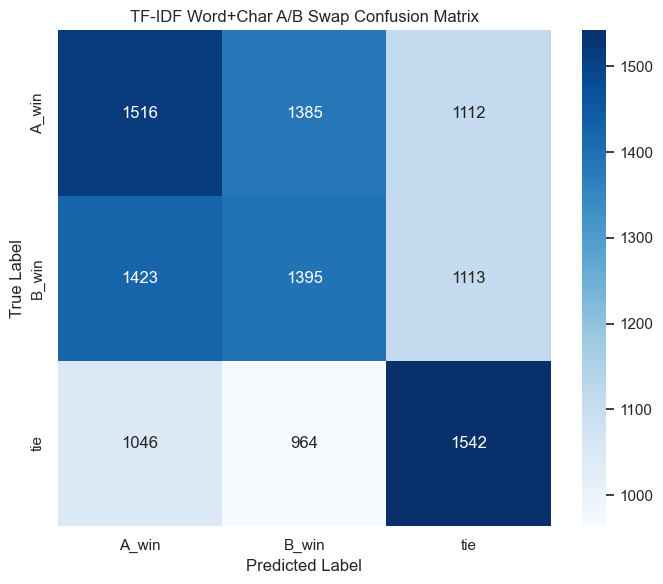

Saved figure: D:\LLM_Classification_finetuning\outputs\figures\tfidf_word_char_ab_swap_confusion_matrix.png


In [10]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=TARGET_NAMES,
    yticklabels=TARGET_NAMES,
)
plt.title('TF-IDF Word+Char A/B Swap Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

confusion_matrix_path = figures_dir / 'tfidf_word_char_ab_swap_confusion_matrix.png'
plt.savefig(confusion_matrix_path, dpi=150)
plt.show()

print(f'Saved figure: {confusion_matrix_path}')

## 11. Save Validation Predictions

Save validation predictions with the best smoothed probabilities.

In [11]:
valid_predictions = valid_split.copy()
valid_predictions['pred_label'] = valid_pred
valid_predictions['pred_label_name'] = valid_predictions['pred_label'].map(LABEL_NAME_MAP)
valid_predictions['prob_A_win'] = best_valid_prob[:, 0]
valid_predictions['prob_B_win'] = best_valid_prob[:, 1]
valid_predictions['prob_tie'] = best_valid_prob[:, 2]
valid_predictions['best_alpha'] = best_alpha

valid_prediction_columns = [
    'id',
    'label',
    'label_name',
    'pred_label',
    'pred_label_name',
    'prob_A_win',
    'prob_B_win',
    'prob_tie',
    'prompt_clean',
    'response_a_clean',
    'response_b_clean',
    'response_a_char_len',
    'response_b_char_len',
    'response_len_diff',
    'best_alpha',
]

valid_predictions_path = oof_dir / 'tfidf_word_char_ab_swap_valid_predictions.csv'
valid_predictions[valid_prediction_columns].to_csv(valid_predictions_path, index=False, encoding='utf-8-sig')

print(f'Saved validation predictions: {valid_predictions_path}')
display(valid_predictions[valid_prediction_columns].head())

Saved validation predictions: D:\LLM_Classification_finetuning\outputs\oof\tfidf_word_char_ab_swap_valid_predictions.csv


,id,label,label_name,pred_label,pred_label_name,prob_A_win,prob_B_win,prob_tie,prompt_clean,response_a_clean,response_b_clean,response_a_char_len,response_b_char_len,response_len_diff,best_alpha
0,2098233919,0,A_win,1,B_win,0.368086,0.369637,0.262276,"How many tires would you estimate are in the city of Detroit, Michigan? Answer in no more than 3 sentences with your reason.\nWhat about the fact that cars ...","I estimate there are over 1 million tires in the city of Detroit, Michigan. As a major metropolitan area, Detroit has hundreds of thousands of registered ve...","It is difficult to provide an exact estimate without specific data, but we can make a rough estimation. Considering the population of Detroit and assuming a...",795,833,-38,0.1
1,2789033728,1,B_win,1,B_win,0.360781,0.361187,0.278032,Write KPI objectives and KPI strategies for Move all companies ISO processes to new ERP,Here are some sample KPI objectives and strategies for moving all company ISO processes to a new ERP system:\n\nKPI Objectives:\n- Complete data migration f...,KPI Objectives:\n1. Successfully migrate all companies' ISO processes to the new ERP system.\n2. Minimize disruption to business operations during the migra...,1504,1599,-95,0.1
2,4198930172,2,tie,0,A_win,0.371834,0.371159,0.257008,Name all the skills of Disco Elysium and format your answer as follows:\nName of skill - Relative rating of usefulness from 0 to 100 - Relative rating of in...,Skills of Disco Elysium:\n\n1. Persuasion - 80\/100 - 80\/100\n2. Intimidation - 80\/100 - 80\/100\n3. Investigation - 80\/100 - 80\/100\n4. Stealth...,"Sure, here are the skills in Disco Elysium, along with their relative ratings of usefulness and interestingness:\n\n1. Intelligence - 90% usefulness, 50% in...",1019,1340,-321,0.1
3,2396441388,1,B_win,2,tie,0.330962,0.331494,0.337545,how do you do patch a hole in drywall?,"Patching a hole in drywall involves a few steps. Here's a general guide:\n\n1. Gather materials: You will need a piece of drywall, drywall mud or joint comp...","Patching a hole in drywall involves several steps, including gathering the necessary tools and materials, preparing the area around the hole, applying a pat...",1644,2188,-544,0.1
4,3592485435,2,tie,0,A_win,0.341388,0.341374,0.317238,"John places his slice of pie in the refrigerator shared by his coworkers, then goes into his office and closes the door. He cannot see the refrigerator. Sus...","The refrigerator cannot communicate with John directly. However, if John notices that his slice of pie is missing, he might conclude that it has been eaten ...",The refrigerator does not have the ability to communicate or tell John anything. It is an inanimate object. John may notice that his pie is missing when he ...,319,171,148,0.1


## 12. Test Prediction with Swap-Test Averaging and Smoothing

Predict original and swapped test inputs, map swapped probabilities back to original order, average, then smooth with the best alpha.

In [12]:
X_test_features = transform_word_char(word_vectorizer, char_vectorizer, test['text_input'])
test_prob_raw = model.predict_proba(X_test_features)
probs_original = align_probabilities(test_prob_raw, model.classes_, LABELS)

test_swapped = swap_ab_dataframe(test.copy())
test_swapped['text_input'] = build_text_input(test_swapped)
X_test_swapped_features = transform_word_char(word_vectorizer, char_vectorizer, test_swapped['text_input'])
test_swapped_prob_raw = model.predict_proba(X_test_swapped_features)
probs_swapped = align_probabilities(test_swapped_prob_raw, model.classes_, LABELS)

mapped_probs_swapped = np.column_stack([
    probs_swapped[:, 1],
    probs_swapped[:, 0],
    probs_swapped[:, 2],
])

avg_probs = 0.5 * probs_original + 0.5 * mapped_probs_swapped
final_probs = smooth_probabilities(avg_probs, best_alpha)

submission = pd.DataFrame({
    'id': test['id'],
    'winner_model_a': final_probs[:, 0],
    'winner_model_b': final_probs[:, 1],
    'winner_tie': final_probs[:, 2],
})

submission_path = submissions_dir / 'tfidf_word_char_ab_swap_smooth_submission.csv'
submission.to_csv(submission_path, index=False, encoding='utf-8-sig')

probability_columns = ['winner_model_a', 'winner_model_b', 'winner_tie']
submission_probability_sum = submission[probability_columns].sum(axis=1)

print(f'Saved submission: {submission_path}')
print(f'submission shape: {submission.shape}')
print(f'submission columns: {submission.columns.tolist()}')
print(f'probability sums close to 1: {np.allclose(submission_probability_sum, 1.0, atol=1e-6)}')
print(f'submission has NaN: {submission.isna().any().any()}')
display(submission.head())

Saved submission: D:\LLM_Classification_finetuning\outputs\submissions\tfidf_word_char_ab_swap_smooth_submission.csv
submission shape: (3, 4)
submission columns: ['id', 'winner_model_a', 'winner_model_b', 'winner_tie']
probability sums close to 1: True
submission has NaN: False


,id,winner_model_a,winner_model_b,winner_tie
0,136060,0.242294,0.242294,0.515413
1,211333,0.349811,0.349150,0.301039
2,1233961,0.403908,0.403908,0.192184


## 13. Save Model Artifacts

Save word vectorizer, char vectorizer, and Logistic Regression model.

In [13]:
word_vectorizer_path = models_dir / 'tfidf_word_vectorizer.joblib'
char_vectorizer_path = models_dir / 'tfidf_char_vectorizer.joblib'
model_path = models_dir / 'tfidf_word_char_ab_swap_logistic_regression.joblib'

joblib.dump(word_vectorizer, word_vectorizer_path)
joblib.dump(char_vectorizer, char_vectorizer_path)
joblib.dump(model, model_path)

print(f'Saved word vectorizer: {word_vectorizer_path}')
print(f'Saved char vectorizer: {char_vectorizer_path}')
print(f'Saved model: {model_path}')

Saved word vectorizer: D:\LLM_Classification_finetuning\outputs\models\tfidf_word_vectorizer.joblib
Saved char vectorizer: D:\LLM_Classification_finetuning\outputs\models\tfidf_char_vectorizer.joblib
Saved model: D:\LLM_Classification_finetuning\outputs\models\tfidf_word_char_ab_swap_logistic_regression.joblib


## 14. Save Experiment Result

Append the experiment result to `outputs/logs/experiment_results.csv`.

In [14]:
experiment_result = pd.DataFrame([
    {
        'model_name': 'tfidf_word_char_ab_swap_smooth',
        'valid_log_loss': best_valid_log_loss,
        'valid_accuracy': valid_accuracy,
        'valid_macro_f1': valid_macro_f1,
        'max_features': 'word_100000_char_50000',
        'ngram_range': 'word_(1,2)_char_(3,5)',
        'C': 0.1,
        'random_state': RANDOM_STATE,
        'notes': 'TF-IDF word + char features with A/B swap augmentation, swap-test averaging, and probability smoothing.',
        'best_alpha': best_alpha,
        'raw_valid_log_loss': raw_valid_log_loss,
        'train_rows_original': len(train_split),
        'train_rows_augmented': len(train_aug),
        'valid_rows': len(valid_split),
    }
])

experiment_results_path = logs_dir / 'experiment_results.csv'

if experiment_results_path.exists():
    previous_results = pd.read_csv(experiment_results_path, encoding='utf-8-sig')
    experiment_results = pd.concat([previous_results, experiment_result], ignore_index=True)
else:
    experiment_results = experiment_result

experiment_results.to_csv(experiment_results_path, index=False, encoding='utf-8-sig')

print(f'Saved experiment results: {experiment_results_path}')
display(experiment_results.tail())

Saved experiment results: D:\LLM_Classification_finetuning\outputs\logs\experiment_results.csv


,model_name,valid_log_loss,valid_accuracy,valid_macro_f1,max_features,ngram_range,C,random_state,notes,model_checkpoint,max_length,train_rows,valid_rows,train_batch_size,eval_batch_size,gradient_accumulation_steps,train_rows_original,train_rows_augmented,best_alpha,raw_valid_log_loss
3,distilbert_debug,1.078858,0.388889,0.376489,NaN,NaN,NaN,42,DistilBERT debug finetuning on at most 1500 samples per class.,distilbert-base-uncased,256.0,3600.0,900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,distilbert_debug,1.078755,0.392222,0.379731,NaN,NaN,NaN,42,DistilBERT debug finetuning on at most 1500 samples per class.,distilbert-base-uncased,256.0,3600.0,900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,distilbert_medium,1.086948,0.371944,0.371848,NaN,NaN,NaN,42,"DistilBERT finetuning on at most 6000 samples per class, max_length=384.",distilbert-base-uncased,384.0,14400.0,3600.0,8.0,16.0,1.0,NaN,NaN,NaN,NaN
6,tfidf_logistic_regression_ab_swap,1.078106,0.395442,0.396300,100000.0,"(1, 2)",0.1,42,TF-IDF Logistic Regression with A/B swap augmentation. Validation set not augmented. Swap-test averaging submission also saved.,NaN,NaN,NaN,11496.0,NaN,NaN,NaN,45981.0,91962.0,NaN,NaN
7,tfidf_word_char_ab_swap_smooth,1.078998,0.387352,0.387994,word_100000_char_50000,"word_(1,2)_char_(3,5)",0.1,42,"TF-IDF word + char features with A/B swap augmentation, swap-test averaging, and probability smoothing.",NaN,NaN,NaN,11496.0,NaN,NaN,NaN,45981.0,91962.0,0.1,1.079283


## 15. Final Checks

Print final metrics, saved files, and finish message.

In [15]:
print(f'best_alpha: {best_alpha}')
print(f'best_valid_log_loss: {best_valid_log_loss:.6f}')
print(f'valid_accuracy: {valid_accuracy:.6f}')
print(f'valid_macro_f1: {valid_macro_f1:.6f}')
print(f'submission shape: {submission.shape}')
print(f'submission probability sums close to 1: {np.allclose(submission_probability_sum, 1.0, atol=1e-6)}')
print(f'submission has NaN: {submission.isna().any().any()}')

print('\nSaved files:')
for path in [
    valid_predictions_path,
    submission_path,
    word_vectorizer_path,
    char_vectorizer_path,
    model_path,
    confusion_matrix_path,
    experiment_results_path,
]:
    print(f'{path.exists()} -> {path}')

print('TF-IDF word+char A/B swap smoothing experiment finished successfully.')

best_alpha: 0.1
best_valid_log_loss: 1.078998
valid_accuracy: 0.387352
valid_macro_f1: 0.387994
submission shape: (3, 4)
submission probability sums close to 1: True
submission has NaN: False

Saved files:
True -> D:\LLM_Classification_finetuning\outputs\oof\tfidf_word_char_ab_swap_valid_predictions.csv
True -> D:\LLM_Classification_finetuning\outputs\submissions\tfidf_word_char_ab_swap_smooth_submission.csv
True -> D:\LLM_Classification_finetuning\outputs\models\tfidf_word_vectorizer.joblib
True -> D:\LLM_Classification_finetuning\outputs\models\tfidf_char_vectorizer.joblib
True -> D:\LLM_Classification_finetuning\outputs\models\tfidf_word_char_ab_swap_logistic_regression.joblib
True -> D:\LLM_Classification_finetuning\outputs\figures\tfidf_word_char_ab_swap_confusion_matrix.png
True -> D:\LLM_Classification_finetuning\outputs\logs\experiment_results.csv
TF-IDF word+char A/B swap smoothing experiment finished successfully.
